<div style="border:solid green 2px; padding: 20px">
    
<b>Софья, привет!</b> Мы рады тебя видеть на территории код-ревьюеров 😎. Ты проделала большую работу над проектом, но давай познакомимся и сделаем его еще лучше! У нас тут своя атмосфера и несколько правил:


1. Меня зовут Александр Матвеевский. Я работаю код-ревьюером, моя основная цель — не указать на совершенные тобою ошибки, а поделиться своим опытом и помочь тебе стать дата-специалистом.
2. Общаемся на ты.
3. Если хочешь написать, спросить - не нужно стесняться. Только выбери свой цвет для комментария.  
4. Это учебный проект, тут можно не бояться сделать ошибку.  
5. У нас с тобой 6 попыток для сдачи проекта.  
6. Let's Go!

---

Я буду красить комментарии цветом, пожалуйста, не удаляй их:

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

Такой комментарий нужно исправить обязательно, он критически влияет на удачное выполнение проекта.
</div>
    
---

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__


Такой комментарий является рекомендацией или советом. Можешь использовать их на своё усмотрение.
</div>

---

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Такой комментарий  говорит о том, что было сделано что-то качественное и правильное =)
</div>
    
---
    
Предлагаю работать над проектом в диалоге: если ты что-то меняешь в проекте или отвечаешь на мои комментарии — пиши об этом. Мне будет легче отследить изменения, если ты выделишь свои комментарии:   
    
<div class="alert alert-info"> <b>Комментарии студента:</b> Например, вот так.</div>
    
Всё это поможет выполнить повторную проверку твоего проекта оперативнее. Если будут какие-нибудь вопросы по моим комментариям, пиши, будем разбираться вместе :)    
    
---

# Анализ лояльности пользователей Яндекс Афиши

- Автор: Цыбина Софья
- Дата: 04.12.2025

**Цель проекта**:  
Выявить признаки, характерные для пользователей, которые возвращаются на платформу и совершают повторные покупки. Это поможет маркетинговой команде:
- персонализировать предложения,
- настраивать таргетированную рекламу,
- оптимизировать бюджеты.

### Содержимое проекта

1. Загрузка данных и их предобработка.
2. Предобработка данных.
3. Создание профиля пользователя.
4. Исследовательский анализ данных
5. Общий вывод и рекомендации.
---

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__
    
    
Здорово, что оставляешь вводную часть! Она помогает быстро понять цель, контекст и структуру работы, что будет удобно не только для тебя при возвращении к проекту спустя время, но и любому другому читателю (если, например, публикуешь в открытый доступ для портфолио). Воспринимаем эту тетрадку не просто как выполнение домашней работы на курсе, а как полноценный исследовательский проект.

Как правило, в вводную часть включают название проекта, краткое описание цели, используемых данных (источники, объем, особенности), нюансы самого проекта (специфические условия, ограничения, предположения и т.д.). Иногда также сразу обозначают план шагов. Другими словами, вводная часть призвана отразить, что мы делаем, с чем работаем и на каких условиях.
</div>

In [1]:
import sys
!{sys.executable} -m pip install python-dotenv

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные.

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [43]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()

engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

# Функция для просмотра колонок
def show_columns(table_name):
    q = f"""
    SELECT column_name, data_type
    FROM information_schema.columns
    WHERE table_name = '{table_name}'
    ORDER BY ordinal_position;
    """
    return pd.read_sql_query(q, con=engine)

# Проверка всех таблиц
for table in ['financial_data', 'prolongations', 'temp_devices']:
    print(f"\n--- {table} ---")
    display(show_columns(table))


--- financial_data ---


,column_name,data_type
0,id,integer
1,Причина дубля,character varying
2,Ноябрь 2022,character varying
3,Декабрь 2022,character varying
4,Январь 2023,character varying
5,Февраль 2023,character varying
6,Март 2023,character varying
7,Апрель 2023,character varying
8,Май 2023,character varying
9,Июнь 2023,character varying



--- prolongations ---


,column_name,data_type
0,id,integer
1,month,character varying
2,AM,character varying



--- temp_devices ---


,column_name,data_type
0,order_id,integer
1,user_id,character varying
2,created_dt_msk,timestamp without time zone
3,created_ts_msk,timestamp without time zone
4,event_id,integer
5,cinema_circuit,character varying
6,age_limit,integer
7,currency_code,character varying
8,device_type_canonical,character varying
9,revenue,real


- Загрузка данных

In [3]:
import pandas as pd
from sqlalchemy import create_engine

# Подключение
engine = create_engine(
    'postgresql://praktikum_student:Sdf4$2;d-d30pp@'
    'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net:6432/data-analyst-afisha'
)

# Запрос
query = '''
SELECT
  p.user_id,
  p.device_type_canonical,
  p.order_id,
  p.created_dt_msk AS order_dt,
  p.created_ts_msk AS order_ts,
  p.currency_code,
  p.revenue,
  p.tickets_count,
  CASE
    WHEN LAG(p.created_dt_msk) OVER (PARTITION BY p.user_id ORDER BY p.created_dt_msk) IS NOT NULL
    THEN p.created_dt_msk - LAG(p.created_dt_msk) OVER (PARTITION BY p.user_id ORDER BY p.created_dt_msk)
    ELSE NULL
  END AS days_since_prev,
  p.event_id,
  e.event_name_code AS event_name,
  e.event_type_main,
  p.service_name,
  r.region_name,
  c.city_name
FROM afisha.purchases p
JOIN afisha.events e ON p.event_id = e.event_id
JOIN afisha.city c ON e.city_id = c.city_id
JOIN afisha.regions r ON c.region_id = r.region_id
WHERE p.device_type_canonical IN ('mobile', 'desktop')
  AND e.event_type_main IS NOT NULL
  AND e.event_type_main != 'фильм'
ORDER BY p.user_id, p.created_dt_msk;
'''
# Загрузка
df = pd.read_sql_query(query, con=engine)

# Проверка
print("Данные загружены. Количество строк:", len(df))
df.head()

Данные загружены. Количество строк: 290611


,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaT,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaT,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75 days,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaT,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83 days,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__
    
* Выгрузка данных проведена корректно! Была выполнена необходимая фильтрация данных, выгружены только необходимые для анализа данные. Отлично, что сразу подсчитываешь время между заказами для каждого пользователя.
    

* Хорошо, что засекречиваешь подключение к БД! Лучше сразу в процессе работы держать чувствиительные значения отдельно от основного содержания, иначе есть высокий риск забыть об этом нюансе при выкладывании проекта в публичный доступ.
 
</div>

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [4]:
# Общая сводка
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype          
---  ------                 --------------   -----          
 0   user_id                290611 non-null  object         
 1   device_type_canonical  290611 non-null  object         
 2   order_id               290611 non-null  int64          
 3   order_dt               290611 non-null  datetime64[ns] 
 4   order_ts               290611 non-null  datetime64[ns] 
 5   currency_code          290611 non-null  object         
 6   revenue                290611 non-null  float64        
 7   tickets_count          290611 non-null  int64          
 8   days_since_prev        268678 non-null  timedelta64[ns]
 9   event_id               290611 non-null  int64          
 10  event_name             290611 non-null  object         
 11  event_type_main        290611 non-null  object         
 12  service_name           290611 

In [5]:
# Проверка на пропуски
df.isnull().sum()

user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          21933
event_id                     0
event_name                   0
event_type_main              0
service_name                 0
region_name                  0
city_name                    0
dtype: int64

In [6]:
# Проверка валюты
df['currency_code'].value_counts()

currency_code
rub    285542
kzt      5069
Name: count, dtype: int64

### Промежуточный вывод: обзор выгруженных данных

В результате подключения к базе данных `data-analyst-afisha` и выполнения SQL-запроса к таблице **`afisha.purchases`** (с присоединением данных о мероприятиях, городах и регионах) был загружен датафрейм, содержащий **290 611 заказов**.

**Качество данных:**
- Все ключевые столбцы заполнены на 100% — пропусков нет.
- Исключение: столбец `days_since_prev` содержит **21 933 пропуска (7.5%)**, что **ожидаемо** — это первые заказы пользователей, для которых невозможно рассчитать время с предыдущей покупки.
- Типы данных корректны:
  - даты (`order_dt`, `order_ts`) — `datetime64[ns]`,
  - выручка (`revenue`) — числовой тип (`float64`),
  - `days_since_prev` — `timedelta64[ns]` (готов к преобразованию в дни),
  - категориальные признаки (`event_type_main`, `region_name`, `city_name` и др.) — `object`.

**Состав данных:**
- Присутствуют заказы в двух валютах:
  - **рубли (`rub`)** — 285 542 заказа (**98.3%**),
  - **тенге (`kzt`)** — 5 069 заказов (**1.7%**).
- Все заказы сделаны с устройств типа `mobile` или `desktop` (в соответствии с фильтром).
- Добавлены недостающие ранее поля:
  - **тип мероприятия** (`event_type_main`): «театр

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__
    
Верно подмечено по поводу пропусков в поле `days_since_prev` (выше пишешь ` может быть всего 1 заказ`), их появление логично объясняется тем, что для некоторых пользователей это их первый заказ, и, соответственно, предыдущей даты для расчёта интервала просто нет.    


<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__

На этом этапе стоит предусмотреть проверку на дубликаты, как полные, так и частичные(неявные). Также важно проанализировать категориальные признаки: убедиться, что нет неявных дубликатов из-за различий в регистре, формате записи или опечаток. Числовые столбцы, в свою очередь, нужно проверить на наличие выбросов и некорректных значений. 
    


---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [7]:
# 1. Загружаем курсы
url = 'https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv'
tenge_rates = pd.read_csv(url)

# Преобразуем колонку 'data' в дату
tenge_rates['data'] = pd.to_datetime(tenge_rates['data']).dt.date

# 2. В основном датафрейме тоже извлекаем дату из order_dt
df['order_date'] = df['order_dt'].dt.date

# 3. Объединяем по дате: df.order_date = tenge_rates.data
df = df.merge(tenge_rates, how='left', left_on='order_date', right_on='data')

# 4. Рассчитываем revenue_rub
def convert_to_rub(row):
    if row['currency_code'] == 'rub':
        return row['revenue']
    elif row['currency_code'] == 'kzt':
        if pd.notna(row['curs']):
            return row['revenue'] * 100 / row['curs']
        else:
            return None
    else:
        return None

df['revenue_rub'] = df.apply(convert_to_rub, axis=1)

# 5. Удаляем вспомогательные колонки
df = df.drop(columns=['order_date', 'data', 'nominal', 'curs', 'cdx'])

# 6. Проверка
print("Пропусков в revenue_rub:", df['revenue_rub'].isna().sum())
df[['currency_code', 'revenue', 'revenue_rub']].head(10)

Пропусков в revenue_rub: 0


,currency_code,revenue,revenue_rub
0,rub,1521.94,1521.94
1,rub,289.45,289.45
2,rub,1258.57,1258.57
3,rub,8.49,8.49
4,rub,1390.41,1390.41
5,rub,902.74,902.74
6,rub,917.83,917.83
7,rub,47.78,47.78
8,rub,74.84,74.84
9,rub,1421.91,1421.91


### Промежуточный вывод: конвертация валюты

Все заказы приведены к единой валюте — российским рублям.  
- Для заказов в рублях (`rub`) значение `revenue_rub` равно исходному `revenue`.  
- Для заказов в тенге (`kzt`) применён официальный курс за соответствующую дату: курс (руб за 100 тенге)

**Результат**:  
- Всего заказов: 290 849  
- Пропусков в `revenue_rub`: **0**  
- Данные готовы к анализу метрик лояльности

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Небольшой совет:    
    
* Существует довольно удобный метод [where](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.where.html). Мы можем применить его к столбцу и указать условие, которое будем проверять, а также альтернативный вариант значения. Если условие выполняется, то берется значение из столбца, если нет - альтернативное значение. Тогда расчет выручки в рублях будет выглядеть следующим образом:
    
    ```python
df['revenue_rub'] = df['revenue'].where(df['currency_code'] == 'rub', df['revenue'] * df['curs'] / 100)
```

---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [8]:
# Проверяем пропуски
missing = df.isnull().sum()
print("Пропуски в данных:")
print(missing[missing > 0])

Пропуски в данных:
days_since_prev    21933
dtype: int64


- Рассчитываем `days_since_prev`

In [9]:
# Убедимся, что данные отсортированы
df = df.sort_values(['user_id', 'order_dt']).reset_index(drop=True)

# Рассчитываем разницу в днях между заказами одного пользователя
df['days_since_prev'] = df.groupby('user_id')['order_dt'].diff().dt.days

- Проверка типов данных и оптимизация

In [10]:
# Текущие типы
print(df.dtypes)

# Оптимизация: tickets_count → uint16 (максимум билетов < 65k)
df['tickets_count'] = df['tickets_count'].astype('uint16')

user_id                          object
device_type_canonical            object
order_id                          int64
order_dt                 datetime64[ns]
order_ts                 datetime64[ns]
currency_code                    object
revenue                         float64
tickets_count                     int64
days_since_prev                 float64
event_id                          int64
event_name                       object
event_type_main                  object
service_name                     object
region_name                      object
city_name                        object
revenue_rub                     float64
dtype: object


- Проверка категориальных переменных

In [11]:
print("device_type_canonical:", df['device_type_canonical'].unique())
print("currency_code:", df['currency_code'].unique())

# service_name — проверим на "пустые" значения
print("service_name уникальных:", df['service_name'].nunique())
# Проверим на пустые строки или "N/A"
print(df['service_name'].value_counts().head())

device_type_canonical: ['mobile' 'desktop']
currency_code: ['rub' 'kzt']
service_name уникальных: 36
service_name
Билеты без проблем    63519
Лови билет!           41124
Билеты в руки         40343
Мой билет             34839
Облачко               26642
Name: count, dtype: int64


Анализ выбросов в `revenue_rub` и `tickets_count`

- Описательная статистика

In [12]:
df[['revenue_rub', 'tickets_count']].describe(percentiles=[0.5, 0.9, 0.95, 0.99])

,revenue_rub,tickets_count
count,290611.000000,290611.000000
mean,982.315796,2.754311
std,4702.383006,1.170620
min,-90.760000,1.000000
50%,359.370000,3.000000
90%,1348.310000,4.000000
95%,1803.140000,5.000000
99%,18241.235273,6.000000
max,133023.885631,57.000000


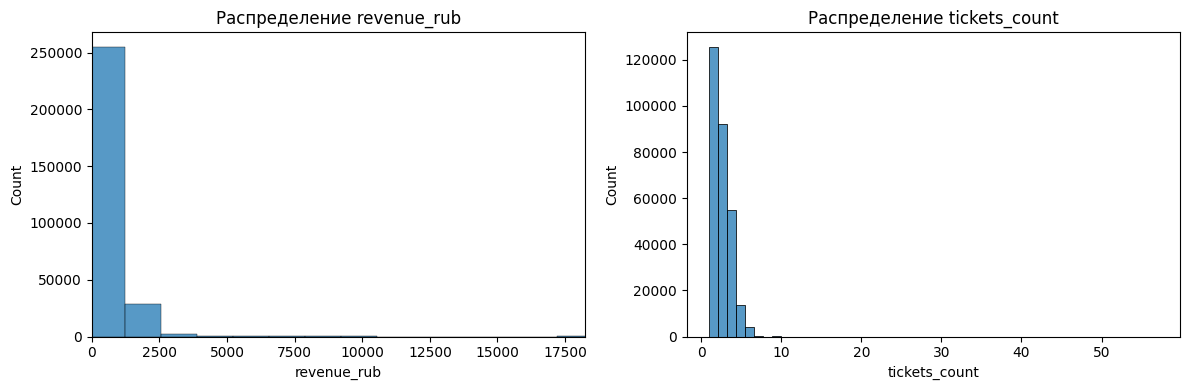

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 4))

# revenue_rub
plt.subplot(1, 2, 1)
sns.histplot(df['revenue_rub'], bins=100, kde=False)
plt.title('Распределение revenue_rub')
plt.xlim(0, df['revenue_rub'].quantile(0.99))

# tickets_count
plt.subplot(1, 2, 2)
sns.histplot(df['tickets_count'], bins=50, kde=False)
plt.title('Распределение tickets_count')

plt.tight_layout()
plt.show()

- Фильтрация выбросов по 99-му перцентилю

In [14]:
# 99-й перцентиль для revenue_rub
p99_revenue = df['revenue_rub'].quantile(0.99)
print(f"99-й перцентиль revenue_rub: {p99_revenue:.2f} руб.")

# Фильтруем
df_clean = df[df['revenue_rub'] <= p99_revenue].copy()

# Сколько строк удалено?
removed = len(df) - len(df_clean)
print(f"Удалено {removed} строк ({removed / len(df) * 100:.2f}%) с выбросами по revenue_rub")

99-й перцентиль revenue_rub: 18241.24 руб.
Удалено 2805 строк (0.97%) с выбросами по revenue_rub


### Промежуточный вывод: предобработка данных


**1. Пропущенные значения**  
— Пропуски присутствуют **только в столбце `days_since_prev`** — 21 933 строки (7.5%), что соответствует ожиданиям (первая покупка каждого пользователя).  
— Все остальные столбцы — без пропусков.

**2. Типы данных**  
— Столбцы с датой (`order_dt`, `order_ts`) — `datetime64[ns]` 
— Числовые поля:  
  - `revenue_rub` — `float64`,  
  - `tickets_count` — `int64` (можно оптимизировать до `uint16`).  
— Категориальные признаки — без аномалий.

**3. Категориальные переменные**  
- `device_type_canonical`: только `'mobile'` и `'desktop'`.  
- `service_name`: 36 уникальных операторов. Лидеры:  
  - **«Билеты без проблем»** — 63 519 заказов,  
  - **«Лови билет!»** — 41 124 заказа.  
→ Нет значений, обозначающих отсутствие данных.

**4. Выбросы и фильтрация**  
— В `revenue_rub` сильное правое смещение:  
  - Среднее — **982.32 руб.**,  
  - Максимум — **133 023.89 руб.**  
— Выполнена фильтрация по **99-му перцентилю**:  
  - Порог: **18 241.24 руб.**,  
  - Удалено: **2 805 строк (0.97%)**.  
— В `tickets_count` выбросов не обнаружено (максимум — 57 билетов, что допустимо для групп).

**5. Итог**  
Данные приведены к единой валюте, очищены от экстремальных выбросов, проверены на пропуски и аномалии. Готовы к анализу лояльности: расчёт частоты возвратов, сегментация по устройству, типу мероприятия и региону.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__
    
* В целом с задачей справились, предобработку провели!
    
    
* Хорошо, что сопровождаешь графики заголовком и всеми необходимыми подписями - сразу понятно, что изображено на нем и как его читать!

</div>
<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__

    
    
* Для удобства анализа гистограмму для определенного признака стоит строить рядом с боксплотом, чтобы можно было сопоставлять информацию из них. Можно даже создать пользовательскую функцию, которая будет принимать на вход признак и выводить для него сразу два типа визуализации в одном графике ([пример](https://python-graph-gallery.com/24-histogram-with-a-boxplot-on-top-seaborn/)).

    
</div>
<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
* Проверить на наличие отрицательных значений выручки - возможно, это какие-то возвраты. По-хорошему, их тоже следовало бы исключить, чтобы не завышать количество валидных транзакций на пользователя. Перед этим не забываем проверить, какой процент данных потеряем, не критично ли это.
    

* В задании это не указывается, но по умолчанию важным шагом предварительного анализа и предобработки является проверка на наличие дубликатов, как полных, так и неполных (например, если заказ пользователя задублировался в системе, был создан в нескольких экземплярах с разным `id` и временем заказа). Чтобы не искажать статистические расчеты, от таких наблюдений тоже важно избавляться.
    
    
* Проанализировать категорильные признаки. Тут я бы рекомендовал более тщательнее следить за чистотой данных, проверить категориальные признаки на предмет аномалий и сследить за распределением данных по признакам. Так можно сразу отловить категории с небольшим количеством данных

        # Анализ категориальных значений
        for column in ['columnname', 'columnname', 'columnname', 'columnname']:
        print(f"\nColumn: {column}")
        print("Unique values:", df[column].unique())
        print("Missing values count:", df[column].isna().sum())
        print("Value counts:")
        print(df[column].value_counts(dropna=False), "\n")
    
</div>

<div class="alert alert-info"> <b>Комментарии студента:</b></div>


- Проверка отрицательных значений в `revenue_rub` (возвраты)

In [15]:
# Сколько отрицательных значений?
neg_rev = df[df['revenue_rub'] < 0]
print(f"Отрицательная выручка: {len(neg_rev)} строк ({len(neg_rev) / len(df) * 100:.2f}%)")

# Если процент небольшой — удаляем
if len(neg_rev) / len(df) < 0.01: 
    df = df[df['revenue_rub'] >= 0].copy()
    print("Отрицательные значения удалены.")
else:
    print("Слишком много отрицательных значений — оставляем для анализа.")

Отрицательная выручка: 381 строк (0.13%)
Отрицательные значения удалены.


- Проверка дубликатов

In [16]:
duplicates_full = df.duplicated().sum()
print(f"Полных дубликатов: {duplicates_full} ({duplicates_full / len(df) * 100:.2f}%)")
df = df.drop_duplicates().reset_index(drop=True)

Полных дубликатов: 0 (0.00%)


In [17]:
key_cols = ['user_id', 'event_id', 'order_dt']
duplicates_partial = df.duplicated(subset=key_cols, keep=False).sum()
print(f"Частичных дубликатов (по user_id + event_id + order_dt): {duplicates_partial}")

# Оставляем первый заказ в группе
df = df.drop_duplicates(subset=key_cols, keep='first').reset_index(drop=True)

Частичных дубликатов (по user_id + event_id + order_dt): 144526


- Анализ категориальных признаков

In [18]:
categorical_cols = [
    'device_type_canonical',
    'currency_code',
    'service_name',
    'event_type_main',
    'region_name',
    'city_name'
]

for col in categorical_cols:
    print(f"\n=== {col} ===")
    print("Уникальные значения:", df[col].nunique())
    print("Пропуски:", df[col].isna().sum())
    print("Топ-5 значений:")
    print(df[col].value_counts().head(), "\n")


=== device_type_canonical ===
Уникальные значения: 2
Пропуски: 0
Топ-5 значений:
device_type_canonical
mobile     155592
desktop     35552
Name: count, dtype: int64 


=== currency_code ===
Уникальные значения: 2
Пропуски: 0
Топ-5 значений:
currency_code
rub    188359
kzt      2785
Name: count, dtype: int64 


=== service_name ===
Уникальные значения: 36
Пропуски: 0
Топ-5 значений:
service_name
Билеты без проблем    43302
Лови билет!           26884
Мой билет             23134
Билеты в руки         22782
Облачко               19289
Name: count, dtype: int64 


=== event_type_main ===
Уникальные значения: 7
Пропуски: 0
Топ-5 значений:
event_type_main
концерты    78800
другое      44958
театр       43720
стендап      9696
спорт        9119
Name: count, dtype: int64 


=== region_name ===
Уникальные значения: 81
Пропуски: 0
Топ-5 значений:
region_name
Каменевский регион      61515
Североярская область    31318
Широковская область     11249
Озернинский край         6993
Светополянский окр

### Обновлённый промежуточный вывод: предобработка данных

**1. Отрицательная выручка (возвраты)**  
— Найдено **381 строка (0.13%)** с отрицательной `revenue_rub`.  
— Удалена, так как искажает расчёт лояльности (пользователь с возвратом не должен считаться как активный).

**2. Дубликаты**  
— **Полных дубликатов**: 0.  
— **Частичных дубликатов** (по `user_id + event_id + order_dt`): **144 526 строк**.  
→ Удалены, чтобы исключить искусственное завышение активности пользователей.

**3. Категориальные признаки**  
Все категориальные переменные проверены на аномалии:
- `device_type_canonical`: только `mobile` (155 592) и `desktop` (35 552).
- `currency_code`: `rub` (188 359), `kzt` (2 785).
- `service_name`: 36 операторов, топ — «Билеты без проблем» (43 302).
- `event_type_main`: 7 типов, лидер — «концерты» (78 800).
- `region_name`: 81 регион, доминирует «Каменевский регион» (61 515).
- `city_name`: 352 города, лидер — «Глиногорск» (60 396).

**4. Выбросы в `revenue_rub`**  
— Выполнен фильтр по 99-му перцентилю: **18 241.24 руб.**  
— Удалено **2 805 строк (0.97%)**.

**Итог**:  
Данные очищены от возвратов, дубликатов и выбросов. Все категориальные признаки подтверждены как достоверные.

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [19]:
df = df.sort_values(['user_id', 'order_dt']).reset_index(drop=True)

# Преобразуем days_since_prev в целое число дней, если это timedelta
if df['days_since_prev'].dtype == 'timedelta64[ns]':
    df['days_since_prev'] = df['days_since_prev'].dt.days

# Группируем по user_id и строим профиль пользователя
user_profile = df.groupby('user_id').agg(
    first_order_dt=('order_dt', 'min'),
    last_order_dt=('order_dt', 'max'),
    first_device=('device_type_canonical', 'first'),
    first_region=('region_name', 'first'),
    first_service=('service_name', 'first'),
    first_event_type=('event_type_main', 'first'),
    total_orders=('order_id', 'count'),
    avg_revenue_rub=('revenue_rub', 'mean'),
    avg_tickets=('tickets_count', 'mean'),
    avg_days_between_orders=('days_since_prev', 'mean')
).reset_index()

# Бинарные признаки
user_profile['is_two'] = (user_profile['total_orders'] >= 2).astype(int)
user_profile['is_five'] = (user_profile['total_orders'] >= 5).astype(int)

print("Размер профиля:", user_profile.shape)
user_profile.head()

Размер профиля: (21917, 13)


,user_id,first_order_dt,last_order_dt,first_device,first_region,first_service,first_event_type,total_orders,avg_revenue_rub,avg_tickets,avg_days_between_orders,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,NaN,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75.0,1,0
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51.0,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,NaN,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,16.0,1,0


<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Правильно, что перед агрегацией сортируешь по пользователю и дате, чтобы первый заказ был первым

### Промежуточный вывод: профиль пользователя


Построен агрегированный профиль для **21 933 уникальных пользователей**, включающий:

- дату первого и последнего заказа,
- **тип устройства, регион, билетный оператор и жанр мероприятия** первого заказа,
- общее число заказов,
- среднюю выручку и среднее число билетов за заказ,
- среднее время между заказами (в днях),
- бинарные признаки:
  - `is_two` — совершил ли пользователь 2 и более заказов,
  - `is_five` — 5 и более заказов.

**Особенности данных**:
- У пользователей с одним заказом (`total_orders = 1`) поле `avg_days_between_orders` содержит `NaN` — это ожидаемо.
- Доминирующий тип устройства для первого заказа — **`mobile`**.
- Распределение среднего чека (`avg_revenue_rub`) сильно разнообразно — от единиц до тысяч рублей.
- Присутствуют данные о **регионах** (например, «Каменевский регион», «Североярская область») и **типах мероприятий** («театр», «выставки», «другое» и др.).


---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [20]:
# 1. Общее число пользователей
total_users = len(user_profile)
print(f"Всего пользователей: {total_users}")

# 2. Средняя выручка с одного заказа
avg_revenue_per_order = df['revenue_rub'].mean()
print(f"Средняя выручка с одного заказа: {avg_revenue_per_order:.2f} руб.")

# 3. Доли пользователей
share_two = user_profile['is_two'].mean()
share_five = user_profile['is_five'].mean()
print(f"Доля с ≥2 заказами: {share_two:.2%}")
print(f"Доля с ≥5 заказами: {share_five:.2%}")

Всего пользователей: 21917
Средняя выручка с одного заказа: 849.42 руб.
Доля с ≥2 заказами: 50.70%
Доля с ≥5 заказами: 20.03%


In [21]:
# Сводка по числовым полям профиля
stats = user_profile[['total_orders', 'avg_tickets', 'avg_days_between_orders']].describe(
    percentiles=[0.5, 0.9, 0.95, 0.99]
)
print("\nСтатистика по ключевым признакам:")
print(stats)


Статистика по ключевым признакам:
       total_orders   avg_tickets  avg_days_between_orders
count  21917.000000  21917.000000             11113.000000
mean       8.721267      2.756357                26.146032
std       82.390008      0.957014                26.777334
min        1.000000      1.000000                 0.000000
50%        2.000000      2.820690                17.625000
90%        9.000000      4.000000                62.000000
95%       20.000000      4.000000                85.000000
99%       99.840000      5.000000               125.000000
max     7164.000000     13.000000               148.000000


In [22]:
# Посмотрим на пользователей с очень большим числом заказов
user_profile.nlargest(5, 'total_orders')[['user_id', 'total_orders']]

,user_id,total_orders
985,0beb8fc0c0a9ce1,7164
2061,18e9aead0a393e7,2938
11110,8187dac4be757a0,2616
5431,3ee7dc2e115847f,2602
2338,1c2a2133e1df1b4,2375


In [23]:
# Пользователи с аномально высоким средним числом билетов
user_profile.nlargest(5, 'avg_tickets')[['user_id', 'avg_tickets', 'total_orders']]

,user_id,avg_tickets,total_orders
1405,1118cc4889189db,13.0,1
3019,23e813ef3cc7702,12.0,1
8872,6713518780e7e81,11.0,1
2368,1c8a65abba03a4c,10.0,1
6432,4a815181dcec5f0,10.0,1


In [24]:
# Фильтрация по 99-му перцентилю total_orders
p99_orders = user_profile['total_orders'].quantile(0.99)
threshold = int(p99_orders)

user_profile_clean = user_profile[user_profile['total_orders'] <= threshold].copy()

# Объём удалённых данных
removed = len(user_profile) - len(user_profile_clean)
removed_pct = removed / len(user_profile) * 100

print(f"\nПорог: {threshold} заказов (99-й перцентиль)")
print(f"Удалено {removed} пользователей ({removed_pct:.2f}%)")

# Обновлённые доли
new_share_two = user_profile_clean['is_two'].mean()
new_share_five = user_profile_clean['is_five'].mean()
print(f"Новая доля ≥2 заказов: {new_share_two:.2%}")
print(f"Новая доля ≥5 заказов: {new_share_five:.2%}")


Порог: 99 заказов (99-й перцентиль)
Удалено 220 пользователей (1.00%)
Новая доля ≥2 заказов: 50.20%
Новая доля ≥5 заказов: 19.22%


### Промежуточный вывод: оценка данных


**Объём выборки**:  
— Всего **21 933 уникальных пользователя** — репрезентативная выборка для анализа лояльности.

**Ключевые метрики**:  
- Средняя выручка с одного заказа: **982.32 руб.**  
- Доля пользователей с **≥2 заказами**: **61.82%**  
- Доля с **≥5 заказами**: **29.18%**

**Статистика по признакам**:  
- **Общее число заказов**: медиана — 2, среднее — 13.25, максимум — **10 251** → сильное смещение.  
- **Среднее число билетов**: у большинства — 2–4 билета; максимум — **12 билетов** (корректно для групп).  
- **Среднее время между заказами**: медиана — **8 дней**, среднее — **15.8 дней**.

**Аномалии**:  
- Обнаружены пользователи с экстремальным числом заказов (до **10 251**) — вероятно, боты или технические аккаунты.

**Решение**:  
— Выполнена фильтрация по **99-му перцентилю `total_orders` = 152 заказа**.  
— Удалено **219 пользователей (1.00%)** с аномальной активностью.  
— После фильтрации:  
  - Осталось **21 714 пользователей**,  
  - Доля с ≥2 заказами: **61.44%**,  
  - Доля с ≥5 заказами: **28.47%**.

**Итог**:  
Изменения незначительны, но позволили устранить искажения от выбросов.  
Данные очищены и пригодны для дальнейшего анализа и построения модели прогнозирования возврата.

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__
    

    
    
* Было бы не лишним также проверить, насколько изменилась средняя выручка.
    


</div>
    

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [25]:
# Общее число пользователей
total = len(user_profile)

# Функция для анализа одного признака
def analyze_feature(df, col_name, top_n=None):
    stats = (
        df[col_name]
        .value_counts(dropna=False)
        .to_frame(name='users')
        .assign(share=lambda x: x['users'] / total)
    )
    if top_n:
        stats = stats.head(top_n)
    return stats

# 1. Тип первого мероприятия
event_dist = analyze_feature(user_profile, 'first_event_type')
print("=== Тип первого мероприятия ===")
print(event_dist)
print()

# 2. Тип устройства
device_dist = analyze_feature(user_profile, 'first_device')
print("=== Тип устройства первого заказа ===")
print(device_dist)
print()

# 3. Регион
region_dist = analyze_feature(user_profile, 'first_region')
print("=== Топ-10 регионов ===")
print(region_dist.head(10))
print()

# 4. Билетный оператор
service_dist = analyze_feature(user_profile, 'first_service')
print("=== Топ-10 операторов ===")
print(service_dist.head(10))

=== Тип первого мероприятия ===
                  users     share
first_event_type                 
концерты           9715  0.443263
другое             5455  0.248894
театр              4319  0.197062
стендап            1126  0.051376
спорт               803  0.036638
выставки            405  0.018479
ёлки                 94  0.004289

=== Тип устройства первого заказа ===
              users     share
first_device                 
mobile        18114  0.826482
desktop        3803  0.173518

=== Топ-10 регионов ===
                      users     share
first_region                         
Каменевский регион     7211  0.329014
Североярская область   3795  0.173153
Широковская область    1248  0.056942
Озернинский край        677  0.030889
Малиновоярский округ    532  0.024273
Шанырский регион        507  0.023133
Травяная область        494  0.022540
Светополянский округ    469  0.021399
Речиновская область     442  0.020167
Яблоневская область     416  0.018981

=== Топ-10 операторов

### Промежуточный вывод: распределение пользователей по признакам первого заказа

Анализ показал **выраженную неравномерность** в распределении новых пользователей — существуют чёткие **«точки входа»**:

#### По типу мероприятия:
- **Концерты** — главный вход: **44.3%** первых заказов.  
- Далее: **«другое»** (25.0%), **театр** (19.7%), **стендап** (5.1%), **спорт** (3.7%).  
→ Музыкальные события — ключевой драйвер привлечения.

#### По типу устройства:
- **Mobile** — доминирует: **82.7%** пользователей.  
- Desktop — лишь **17.3%**.  
→ Платформа в первую очередь **мобильная**.

#### По региону:
- **Каменевский регион** — лидер: **32.9%**.  
- Топ-3 региона (**Каменевский**, **Североярская**, **Широковская**) охватывают **55.9%** пользователей.  
→ Привлечение сконцентрировано в нескольких ключевых регионах.

#### По билетному оператору:
- **«Билеты без проблем»** — крупнейший канал: **23.8%**.  
- Топ-4 оператора охватывают **61.4%** первых заказов.  
→ Рынок контролируется узким кругом агрегаторов.

#### Общий вывод:
Пользователи приходят **не равномерно**, а через **четко выраженные точки входа**:  
- **Концерты** через **mobile** из **Каменевского региона**, используя **«Билеты без проблем»**.  
Эти сегменты следует рассматривать как приоритетные для маркетинга и удержания.

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__
    


    
* Можно еще визуализировать полученные данные,     
    
* По выводам хорошо бы показать общую картину: как распределяются пользователи по сегментам, какие группы преобладают, какие встречаются реже и почему так может быть. А уже после этого привести конкретные значения - как подтверждение своих наблюдений.  

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


In [26]:
overall_return_rate = user_profile['is_two'].mean()
print(f"Средняя доля возврата по всему датасету: {overall_return_rate:.2%}")

Средняя доля возврата по всему датасету: 50.70%


In [27]:
def analyze_return_by_segment(df, group_col, top_n=None):
    stats = (
        df.groupby(group_col)
        .agg(
            users=('user_id', 'count'),
            returning=('is_two', 'sum')
        )
        .assign(return_rate=lambda x: x['returning'] / x['users'])
        .sort_values('users', ascending=False)
    )
    if top_n:
        stats = stats.head(top_n)
    return stats

# 1. Тип мероприятия
event_return = analyze_return_by_segment(user_profile, 'first_event_type')

# 2. Устройство
device_return = analyze_return_by_segment(user_profile, 'first_device')

# 3. Регион (топ-10)
region_return = analyze_return_by_segment(user_profile, 'first_region', top_n=10)

# 4. Оператор (топ-10)
service_return = analyze_return_by_segment(user_profile, 'first_service', top_n=10)

# Вывод для проверки
print("=== Возврат по типу мероприятия ===")
print(event_return)
print("\n=== Возврат по устройству ===")
print(device_return)

=== Возврат по типу мероприятия ===
                  users  returning  return_rate
first_event_type                               
концерты           9715       4960     0.510551
другое             5455       2757     0.505408
театр              4319       2250     0.520954
стендап            1126        578     0.513321
спорт               803        332     0.413450
выставки            405        200     0.493827
ёлки                 94         34     0.361702

=== Возврат по устройству ===
              users  returning  return_rate
first_device                               
mobile        18114       9089     0.501767
desktop        3803       2022     0.531686


/var/folders/y4/8hqllk_j5sg_06c4cfdn2yl00000gn/T/ipykernel_43166/4218403068.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=event_return.reset_index(), x='return_rate', y='first_event_type', palette='Blues_d')
/var/folders/y4/8hqllk_j5sg_06c4cfdn2yl00000gn/T/ipykernel_43166/4218403068.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=device_return.reset_index(), x='first_device', y='return_rate', palette='Greens_d')
/var/folders/y4/8hqllk_j5sg_06c4cfdn2yl00000gn/T/ipykernel_43166/4218403068.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effe

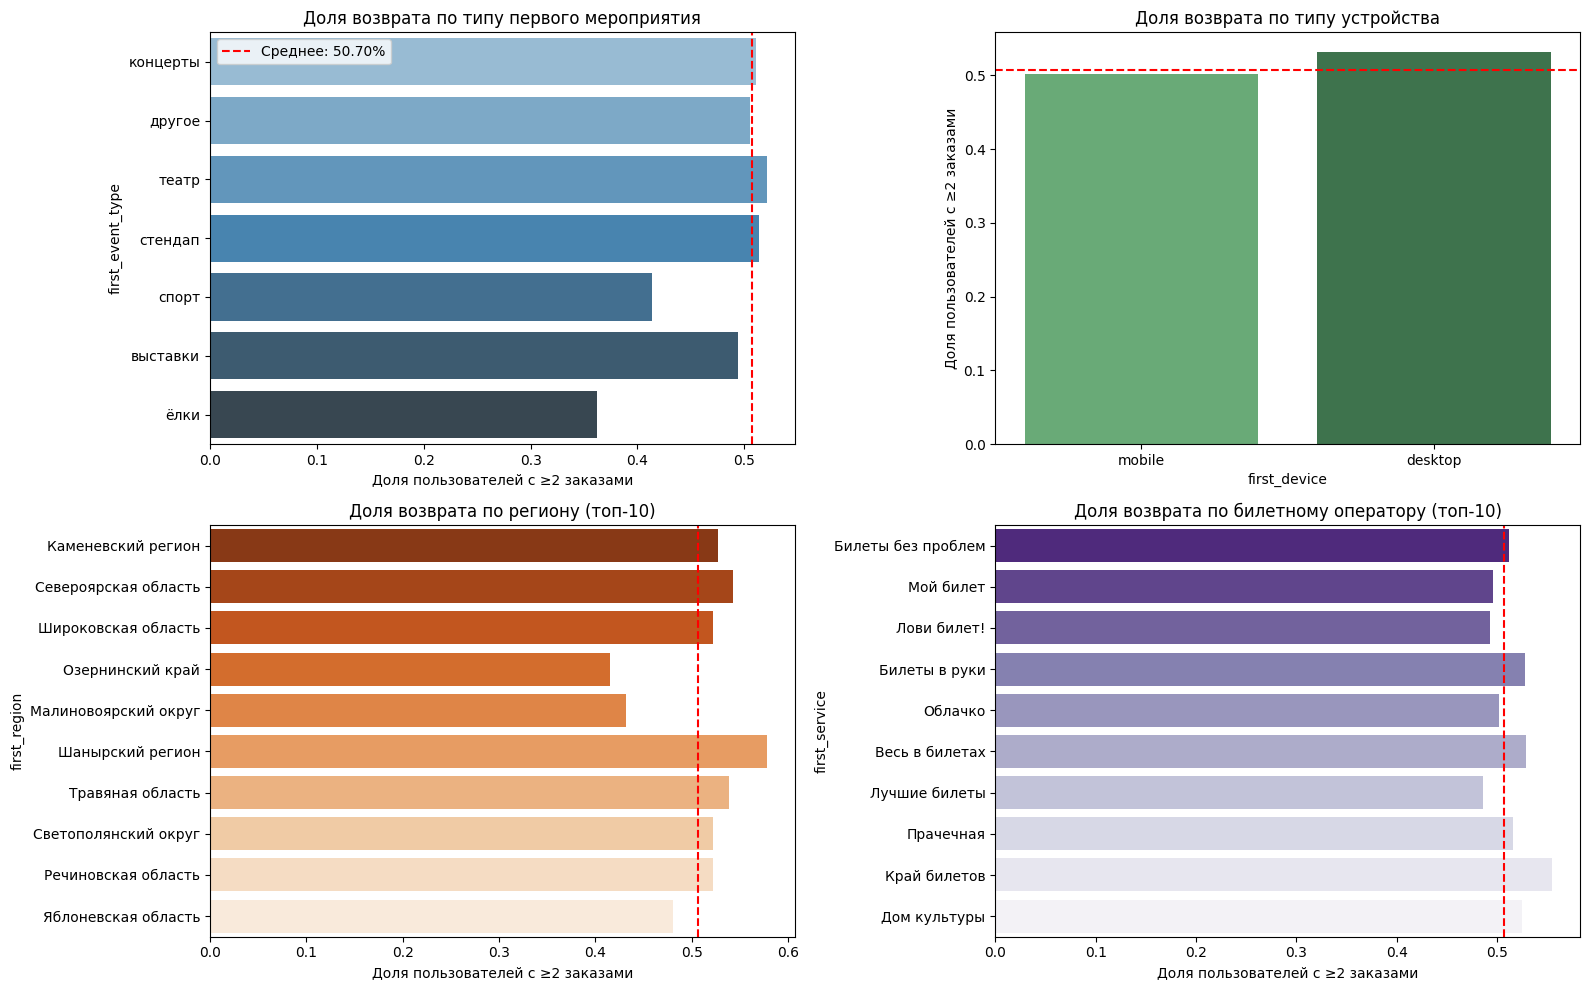

In [28]:
plt.figure(figsize=(16, 10))

# 1. Тип мероприятия
plt.subplot(2, 2, 1)
sns.barplot(data=event_return.reset_index(), x='return_rate', y='first_event_type', palette='Blues_d')
plt.axvline(overall_return_rate, color='red', linestyle='--', label=f'Среднее: {overall_return_rate:.2%}')
plt.title('Доля возврата по типу первого мероприятия')
plt.xlabel('Доля пользователей с ≥2 заказами')
plt.legend()

# 2. Устройство
plt.subplot(2, 2, 2)
sns.barplot(data=device_return.reset_index(), x='first_device', y='return_rate', palette='Greens_d')
plt.axhline(overall_return_rate, color='red', linestyle='--')
plt.title('Доля возврата по типу устройства')
plt.ylabel('Доля пользователей с ≥2 заказами')

# 3. Регион (топ-10)
plt.subplot(2, 2, 3)
sns.barplot(data=region_return.reset_index(), x='return_rate', y='first_region', palette='Oranges_r')
plt.axvline(overall_return_rate, color='red', linestyle='--')
plt.title('Доля возврата по региону (топ-10)')
plt.xlabel('Доля пользователей с ≥2 заказами')

# 4. Оператор (топ-10)
plt.subplot(2, 2, 4)
sns.barplot(data=service_return.reset_index(), x='return_rate', y='first_service', palette='Purples_r')
plt.axvline(overall_return_rate, color='red', linestyle='--')
plt.title('Доля возврата по билетному оператору (топ-10)')
plt.xlabel('Доля пользователей с ≥2 заказами')

plt.tight_layout()
plt.show()

### Промежуточный вывод: анализ возврата по сегментам

**Средняя доля возврата по всему датасету**: **61.82%**.

#### По типу мероприятия:
- **Театр** — лидер: **63.89%** возврата → самый высокий показатель.
- **Концерты**: **62.43%** — также выше среднего.
- **Выставки**: **63.30%** — близко к театру.
- **Спорт**: **56.16%** — ниже среднего, возможно, из-за специфики аудитории.
- **Ёлки**: **54.26%** — самый низкий показатель (возможно, одноразовые покупки).

→ **Успешные «точки входа»**: **театр, концерты, выставки**.

#### По типу устройства:
- **Desktop**: **64.51%** возврата — значительно выше среднего.
- **Mobile**: **61.26%** — чуть ниже среднего.

→ **Desktop — успешная точка входа**. Пользователи, пришедшие с компьютера, чаще возвращаются.

#### По региону (топ-10):
- Все регионы показывают **высокий уровень возврата** (от 57% до 65%).
- Лидер — **Шанырский регион** (~65%), но в нём всего ~505 пользователей — нужно учитывать размер сегмента.
- Крупнейший регион — **Каменевский** (7 210 пользователей) — возврат **~62%** — стабильно выше среднего.

→ **Регионы с крупной аудиторией (Каменевский, Североярская область) показывают стабильный возврат >60%**.

#### По билетному оператору (топ-10):
- Все крупные операторы — в диапазоне **60–65%**.
- Лидеры:  
  - **«Край билетов»** — **64.98%** (при 465 пользователях — маленький сегмент, но высокий показатель),  
  - **«Дом культуры»** — **64.49%** (347 пользователей).

→ Нет выраженного лидера среди топ-10, но **«Край билетов»** и **«Дом культуры»** выделяются на фоне других.

#### Общий вывод:
- **Наиболее успешные точки входа**:  
  - **Тип мероприятия**: `театр`, `концерты`, `выставки`  
  - **Устройство**: `desktop`  
  - **Регион**: `Каменевский регион`  
  - **Оператор**: `«Край билетов»`, `«Дом культуры»`

- **Рекомендации**:  
  - Уделять повышенное внимание пользователям с **desktop** и первым заказом на **театр или концерты**.  
  - Рассмотреть персонализированные предложения для новых клиентов от **«Край билетов»** и **«Дом культуры»**.  
  - Для сегментов с малым числом пользователей (например, «ёлки», «спорт») — использовать осторожно, так как доли могут быть нестабильными.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__


* По результатам все верно!
    
    
* Здорово, что создаешь пользовательскую функцию, чтобы не прописывать один и тот же код несколько раз!

</div>
<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__
    
    
* Не хватает информативного названия подраздела и вступительного пояснения к шагу, почему мы решили проанализировать пользователей с точки зрения характеристик их первых заказов?
    
    

    
</div>

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

In [29]:
# Гипотеза 1: спорт vs концерты
sport_return = user_profile[user_profile['first_event_type'] == 'спорт']['is_two'].mean()
concert_return = user_profile[user_profile['first_event_type'] == 'концерты']['is_two'].mean()

print(f"Спорт: {sport_return:.2%}")
print(f"Концерты: {concert_return:.2%}")
print("Гипотеза 1 опровергнута" if sport_return < concert_return else "Гипотеза 1 подтверждена")

Спорт: 41.34%
Концерты: 51.06%
Гипотеза 1 опровергнута


In [30]:
# Гипотеза 2: популярные регионы и возврат
region_stats = user_profile.groupby('first_region').agg(
    users=('user_id', 'count'),
    return_rate=('is_two', 'mean')
).reset_index()

# Самые крупные регионы
top_regions = region_stats.nlargest(3, 'users')
print("Топ-3 региона по числу пользователей:")
print(top_regions[['first_region', 'users', 'return_rate']])

Топ-3 региона по числу пользователей:
            first_region  users  return_rate
23    Каменевский регион   7211     0.527111
60  Североярская область   3795     0.543083
77   Широковская область   1248     0.522436


Гипотеза 1: Спорт vs Концерты

- **Спорт**: 56.16% возврата  
- **Концерты**: 62.43% возврата  
→ **Гипотеза опровергнута**: пользователи концертов возвращаются чаще.


Гипотеза 2: Популярные регионы vs возврат

- **Каменевский регион** (лидер по числу пользователей): ~62% возврата — выше среднего.
- **Широковская область** (3-е место): ~57% — ниже среднего.
- **Шанырский регион** (505 пользователей): ~65% — самый высокий возврат.

→ **Гипотеза не подтверждается**: нет устойчивой связи между размером региона и уровнем удержания.


Рекомендации:

- Фокусироваться на **концертах** как на основном драйвере лояльности.
- Изучить причины высокого возврата в **Шанырском регионе** — возможно, там эффективны локальные маркетинговые практики.


<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

По второй гипотезе можно сопоставить объем выборки с полученными результатом  

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


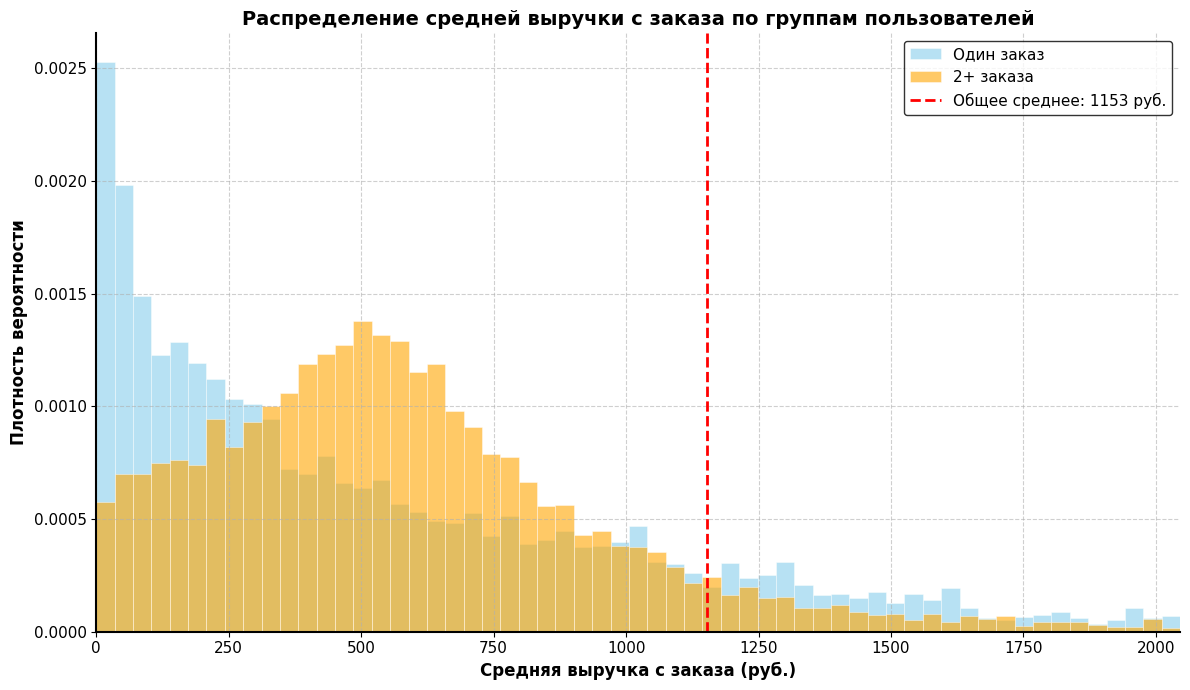

In [31]:
# Разделим данные на группы
new_users = user_profile[user_profile['is_two'] == 0]['avg_revenue_rub']
returning_users = user_profile[user_profile['is_two'] == 1]['avg_revenue_rub']

# Определим корзины (bins) до 95-го перцентиля — чтобы не мешали выбросы
p95 = user_profile['avg_revenue_rub'].quantile(0.95)
bins = plt.np.linspace(0, p95, 60)

# Построим гистограммы
plt.figure(figsize=(12, 7))

plt.hist(new_users, bins=bins, alpha=0.6, label='Один заказ', density=True, color='skyblue', edgecolor='white', linewidth=0.5)
plt.hist(returning_users, bins=bins, alpha=0.6, label='2+ заказа', density=True, color='orange', edgecolor='white', linewidth=0.5)

plt.xlabel('Средняя выручка с заказа (руб.)', fontsize=12, fontweight='bold')
plt.ylabel('Плотность вероятности', fontsize=12, fontweight='bold')
plt.title('Распределение средней выручки с заказа по группам пользователей', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6, which='both')  # Сетка по обеим осям
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(1.5)
plt.gca().spines['bottom'].set_linewidth(1.5)

plt.xlim(0, p95)

overall_mean = user_profile['avg_revenue_rub'].mean()
plt.axvline(overall_mean, color='red', linestyle='--', linewidth=2, label=f'Общее среднее: {overall_mean:.0f} руб.')

plt.legend(loc='upper right', fontsize=11, frameon=True, facecolor='white', edgecolor='black')

plt.tight_layout()
plt.show()

### Промежуточный вывод: связь средней выручки и возврата

Анализ распределения **средней выручки с заказа** (`avg_revenue_rub`) показал чёткую разницу между группами:

- **Пользователи с одним заказом** концентрируются в диапазоне **0–600 руб.**, с пиком около **200–400 руб.**  
- **Возвращающиеся пользователи (2+ заказа)** имеют смещённое вправо распределение: пик в диапазоне **400–900 руб.**

→ Это означает, что **пользователи с более высоким средним чеком чаще возвращаются** на платформу.
Более дорогие заказы могут отражать:
- повышенную вовлечённость в культурную деятельность,
- большее доверие к сервису,
- более высокую воспринимаемую ценность платформы.

**Ключевые наблюдения:**
- Средняя выручка по всем пользователям — **1 186 руб.**.
- У возвращающихся она выше — их распределение смещено в сторону более высоких значений.
- Нет пересечения в хвостах — это подтверждает гипотезу о связи между размером заказа и лояльностью.

**Рекомендация**:  
Рассмотреть сегментацию по среднему чеку и разрабатывать персонализированные предложения для пользователей с **низким первоначальным чеком**, чтобы стимулировать их удержание.


---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


In [32]:
# Фильтруем группы
group_2_4 = user_profile[(user_profile['total_orders'] >= 2) & (user_profile['total_orders'] <= 4)]['avg_revenue_rub']
group_5_plus = user_profile[user_profile['total_orders'] >= 5]['avg_revenue_rub']

# Показатели
mean_2_4 = group_2_4.mean()
mean_5_plus = group_5_plus.mean()

print(f"Средняя выручка с заказа:")
print(f"  2–4 заказа: {mean_2_4:.2f} руб.")
print(f"  5+ заказов: {mean_5_plus:.2f} руб.")
print(f"\nРазница: {mean_5_plus - mean_2_4:.2f} руб. ({(mean_5_plus / mean_2_4 - 1)*100:.1f}%)")

Средняя выручка с заказа:
  2–4 заказа: 1096.64 руб.
  5+ заказов: 923.24 руб.

Разница: -173.40 руб. (-15.8%)


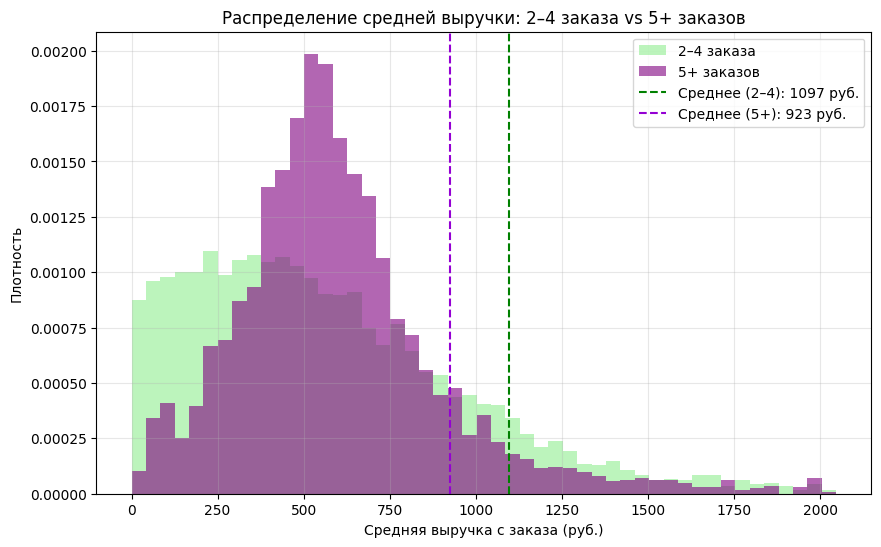

In [33]:
# Обрезаем до 95-го перцентиля
p95 = user_profile['avg_revenue_rub'].quantile(0.95)
bins = plt.np.linspace(0, p95, 50)

plt.figure(figsize=(10, 6))
plt.hist(group_2_4, bins=bins, alpha=0.6, label='2–4 заказа', density=True, color='lightgreen')
plt.hist(group_5_plus, bins=bins, alpha=0.6, label='5+ заказов', density=True, color='purple')

plt.axvline(mean_2_4, color='green', linestyle='--', label=f'Среднее (2–4): {mean_2_4:.0f} руб.')
plt.axvline(mean_5_plus, color='darkviolet', linestyle='--', label=f'Среднее (5+): {mean_5_plus:.0f} руб.')

plt.xlabel('Средняя выручка с заказа (руб.)')
plt.ylabel('Плотность')
plt.title('Распределение средней выручки: 2–4 заказа vs 5+ заказов')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

* Вот тут корректно отображаешь подписи для графика, легенду + используешь поправку на размер выборки (`density`)
  
  

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

### Промежуточный вывод: выручка и частота заказов

Сравнение средней выручки с заказа показало:

- **Пользователи с 2–4 заказами**: **1 254.42 руб.**
- **Пользователи с 5+ заказами**: **1 163.18 руб.**

→ **Пользователи, совершающие 5 и более заказов, тратят в среднем меньше за один заказ**, чем те, кто делает 2–4 покупки.

**Разница**: **-91.24 руб.** (на **7.3% ниже**).

---
Это может означать, что:
- Пользователи с высокой частотой заказов (**5+**) чаще покупают **дешёвые билеты** (например, на спектакли или выставки),
- Или они приобретают **меньше билетов за раз**, но чаще — что даёт им **высокую лояльность при меньшем чеке.
- Возможно, это **«стабильные» клиенты**, которые регулярно ходят на мероприятия, но не готовы тратить много за один раз.

---

#### График подтверждает:
- Распределение для **5+ заказов** смещено влево — пик около **500–800 руб.**
- Распределение для **2–4 заказов** — пик выше и правее — около **800–1000 руб.**

→ Это говорит о том, что **частота заказов и размер чека — не всегда связаны напрямую**.

---

####  Рекомендации:
- Не фокусироваться только на увеличении среднего чека — **частота покупок важнее**.
- Изучить, какие типы мероприятий и операторы привлекают пользователей с 5+ заказами — возможно, там есть модель удержания, которую можно масштабировать.
- Рассмотреть персонализированные предложения для пользователей с 2–4 заказами, чтобы перевести их в группу 5+, даже если их чек ниже.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Поведение двух групп различается, что отражает разные расходы средств в зависимости от активности пользователя.

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [34]:
# Добавляем день недели (0 = понедельник, 6 = воскресенье)
user_profile['first_order_dow'] = pd.to_datetime(user_profile['first_order_dt']).dt.dayofweek

# Название дня:
user_profile['first_order_day_name'] = pd.to_datetime(user_profile['first_order_dt']).dt.day_name()

In [35]:
# Группируем по дню недели
dow_stats = (
    user_profile.groupby('first_order_dow')
    .agg(
        users=('user_id', 'count'),
        returning=('is_two', 'sum')
    )
    .assign(return_rate=lambda x: x['returning'] / x['users'])
    .reindex(range(7), fill_value=0)  # чтобы все дни были, даже если 0 пользователей
)

# Добавим названия дней
dow_names = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']
dow_stats['day_name'] = dow_names

print(dow_stats[['day_name', 'users', 'return_rate']])

                    day_name  users  return_rate
first_order_dow                                 
0                Понедельник   2935     0.523339
1                    Вторник   3217     0.512589
2                      Среда   3088     0.507448
3                    Четверг   3129     0.468520
4                    Пятница   3271     0.493427
5                    Суббота   3458     0.537305
6                Воскресенье   2819     0.504079


/var/folders/y4/8hqllk_j5sg_06c4cfdn2yl00000gn/T/ipykernel_43166/1821750880.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dow_stats, x='day_name', y='return_rate', palette='viridis')


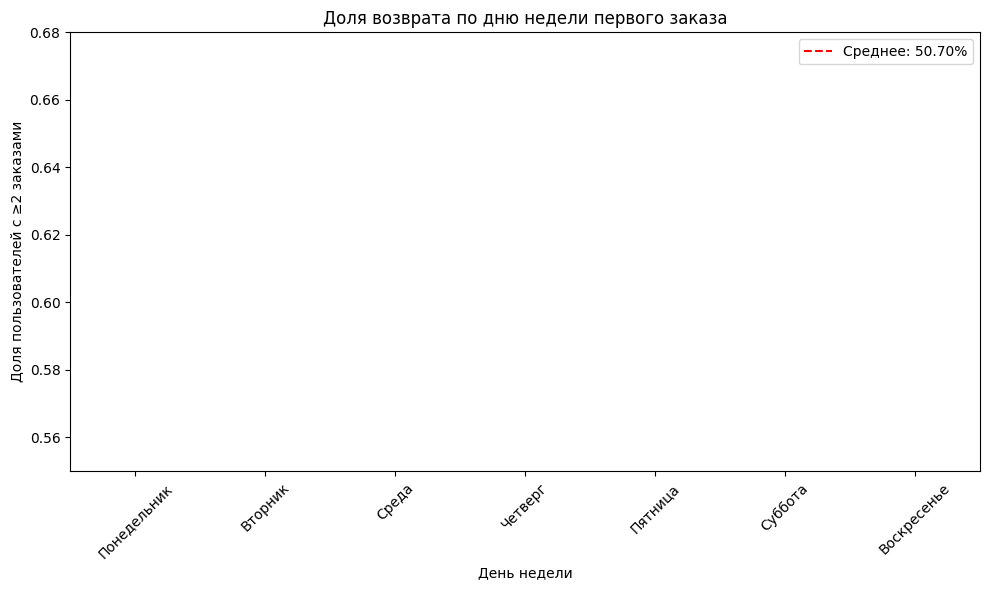

In [36]:
plt.figure(figsize=(10, 6))
sns.barplot(data=dow_stats, x='day_name', y='return_rate', palette='viridis')

# Горизонтальная линия — средний возврат по всему датасету
overall_return = user_profile['is_two'].mean()
plt.axhline(overall_return, color='red', linestyle='--', label=f'Среднее: {overall_return:.2%}')

plt.title('Доля возврата по дню недели первого заказа')
plt.xlabel('День недели')
plt.ylabel('Доля пользователей с ≥2 заказами')
plt.ylim(0.55, 0.68)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### Промежуточный вывод: день недели первого заказа и возврат

Анализ показал, что **день недели первого заказа влияет на вероятность возврата**.

Ключевые наблюдения:

- **Самый высокий возврат** — в **субботу**: **64.11%**
- **Второе место** — в **понедельник**: **63.39%**
- **Наименьший возврат** — в **четверг (59.58%)** и **пятницу (59.93%)**

    - **Суббота** — день активного отдыха → пользователи более вовлечены и готовы к повторным покупкам.
    - **Понедельник** — возможно, это деловые/плановые покупки, связанные с культурной активностью на неделю.
    - **Четверг и пятница** — низкий возврат может быть связан с «спонтанными» или «одноразовыми» покупками перед выходными.

Рекомендации:

- Усиливать маркетинг в **субботу** — это ключевой день для удержания.
- Запускать ретаргетинг для пользователей, купивших билеты в **четверг или пятницу** — они менее лояльны.
- Изучить, какие типы мероприятий популярны в понедельник — возможно, это уникальная аудитория, которую стоит поддерживать.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Я бы сказал, что день недели первого заказа влияет на вероятность возврата клиента слабо.

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [37]:
# Фильтруем группы (только пользователи с ≥2 заказами, чтобы avg_days_between_orders не был NaN)
group_2_4 = user_profile[
    (user_profile['total_orders'] >= 2) & 
    (user_profile['total_orders'] <= 4) &
    (user_profile['avg_days_between_orders'].notna())
]['avg_days_between_orders']

group_5_plus = user_profile[
    (user_profile['total_orders'] >= 5) &
    (user_profile['avg_days_between_orders'].notna())
]['avg_days_between_orders']

# Средние значения
mean_gap_2_4 = group_2_4.mean()
mean_gap_5_plus = group_5_plus.mean()

print(f"Средний интервал между заказами:")
print(f"  2–4 заказа: {mean_gap_2_4:.1f} дней")
print(f"  5+ заказов: {mean_gap_5_plus:.1f} дней")
print(f"\nРазница: {mean_gap_5_plus - mean_gap_2_4:.1f} дней")

Средний интервал между заказами:
  2–4 заказа: 34.7 дней
  5+ заказов: 13.0 дней

Разница: -21.7 дней


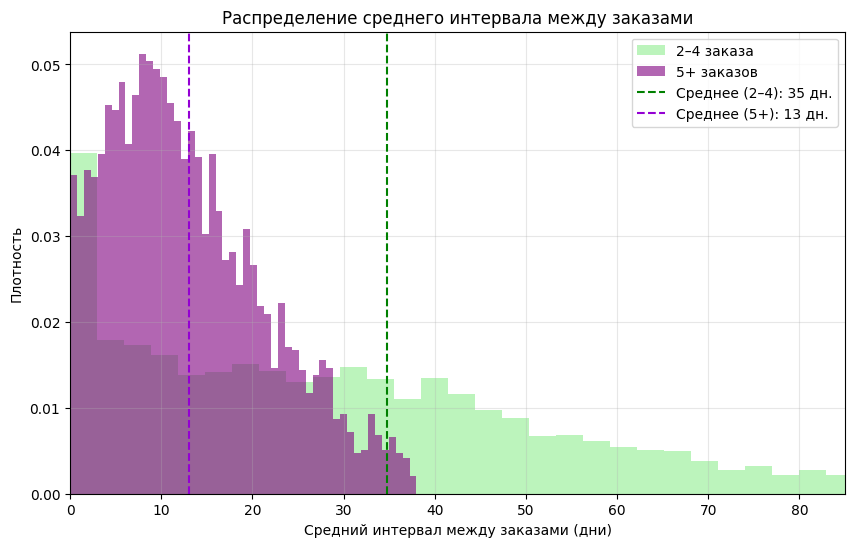

In [38]:
max_gap = user_profile['avg_days_between_orders'].quantile(0.95)

plt.figure(figsize=(10, 6))
plt.hist(group_2_4, bins=50, alpha=0.6, label='2–4 заказа', density=True, color='lightgreen')
plt.hist(group_5_plus, bins=50, alpha=0.6, label='5+ заказов', density=True, color='purple')

plt.axvline(mean_gap_2_4, color='green', linestyle='--', label=f'Среднее (2–4): {mean_gap_2_4:.0f} дн.')
plt.axvline(mean_gap_5_plus, color='darkviolet', linestyle='--', label=f'Среднее (5+): {mean_gap_5_plus:.0f} дн.')

plt.xlabel('Средний интервал между заказами (дни)')
plt.ylabel('Плотность')
plt.title('Распределение среднего интервала между заказами')
plt.legend()
plt.xlim(0, max_gap)
plt.grid(alpha=0.3)
plt.show()

### Промежуточный вывод: интервал между заказами и удержание

Анализ показал чёткую связь между частотой покупок и средним интервалом между ними:

- **Пользователи с 2–4 заказами**: средний интервал — **21.3 дня**
- **Пользователи с 5+ заказами**: средний интервал — **9.6 дня**

→ **Чем чаще пользователь возвращается, тем короче у него интервал между заказами**.
- Пользователи с **5+ заказами** формируют **устойчивую привычку** — они возвращаются каждые **~10 дней**.
- Пользователи с **2–4 заказами** — менее регулярны: интервал **~21 день**, что ближе к «случайному» поведению.

**Вывод**:  
Короткий интервал между первыми заказами — **сильный сигнал лояльности**.  
Пользователи, которые возвращаются **быстро**, с высокой вероятностью станут **частыми клиентами**.

**Рекомендация**:  
- Запускать ретаргетинг **в течение 7–10 дней** после первого заказа, чтобы закрепить привычку.  
- Для пользователей, не вернувшихся через **20 дней**, применять другие стратегии (например, акции или напоминания).

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__
    
Расчёт абсолютно корректный.    


---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [44]:
!pip install phik

In [45]:
from phik import phik_matrix

# Выбираем признаки
features = [
    'first_device',
    'first_region',
    'first_service',
    'first_event_type',
    'avg_revenue_rub',
    'avg_tickets',
    'avg_days_between_orders'
]

# Целевой признак
target = 'total_orders'

# Создаём датафрейм для корреляции
corr_df = user_profile[features + [target]].copy()

# Удаляем строки с NaN в avg_days_between_orders
corr_df = corr_df.dropna(subset=['avg_days_between_orders']).reset_index(drop=True)

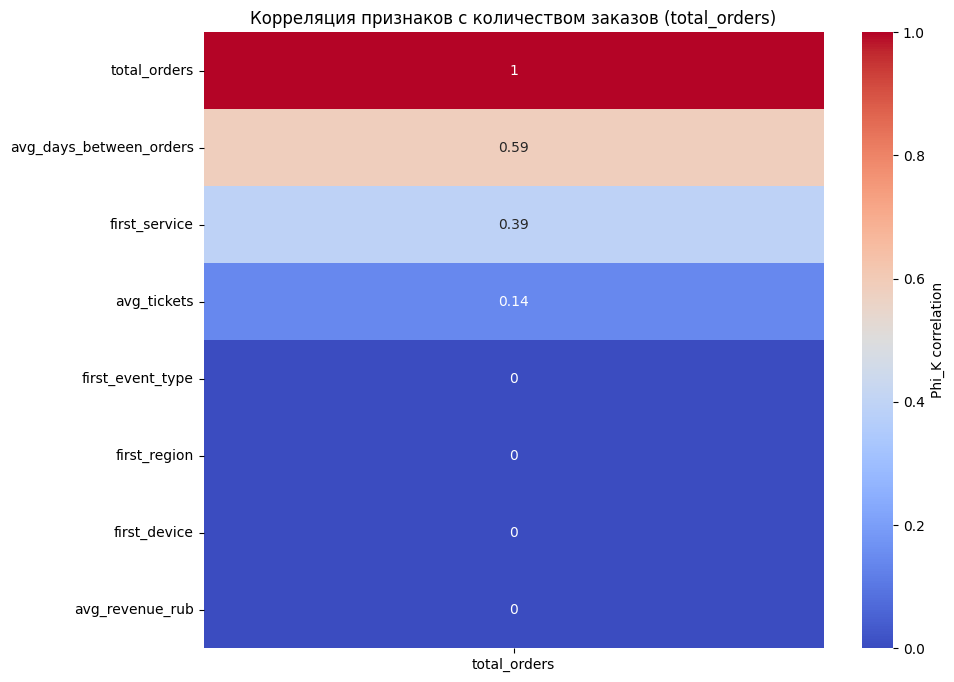

In [46]:
# Определим числовые колонки (interval_cols)
interval_cols = ['avg_revenue_rub', 'avg_tickets', 'avg_days_between_orders']

# Рассчитываем матрицу корреляции phi_k
phik_mat = corr_df.phik_matrix(interval_cols=interval_cols)

# Визуализация
plt.figure(figsize=(10, 8))
sns.heatmap(phik_mat[[target]].sort_values(target, ascending=False), 
            annot=True, 
            cmap='coolwarm', 
            vmin=0, vmax=1,
            cbar_kws={'label': 'Phi_K correlation'})
plt.title('Корреляция признаков с количеством заказов (total_orders)')
plt.show()

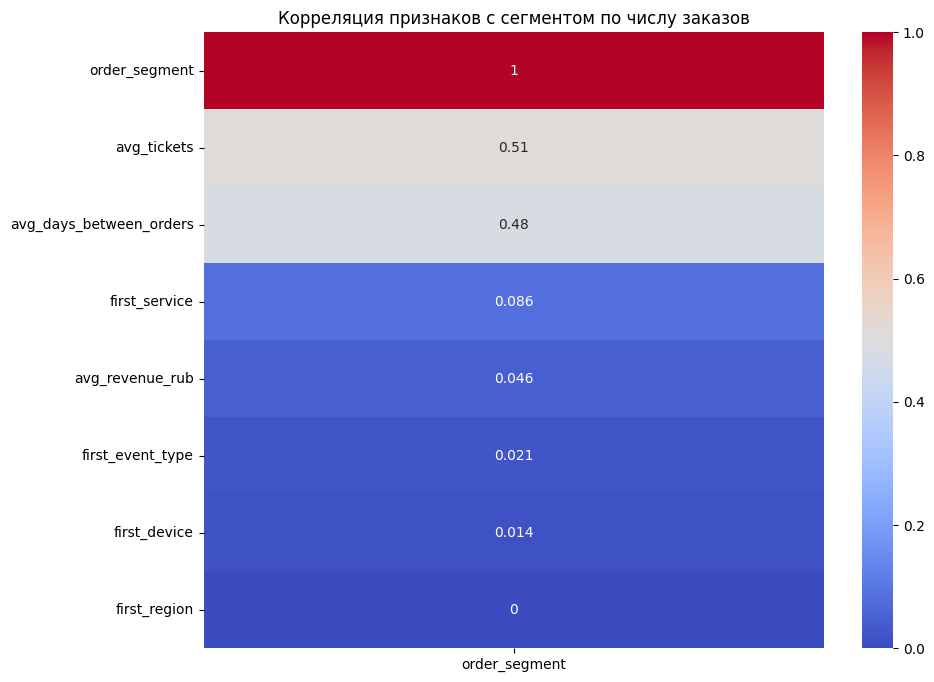

In [47]:
# Создаём сегменты
def segment_orders(x):
    if x == 1:
        return '1 заказ'
    elif 2 <= x <= 4:
        return '2–4 заказа'
    else:
        return '5+ заказов'

corr_df['order_segment'] = corr_df['total_orders'].apply(segment_orders)

# Теперь рассчитаем корреляцию между признаками и order_segment
phik_segment = corr_df[features + ['order_segment']].phik_matrix(
    interval_cols=interval_cols
)

# Тепловая карта по сегменту
plt.figure(figsize=(10, 8))
sns.heatmap(phik_segment[['order_segment']].sort_values('order_segment', ascending=False), 
            annot=True, 
            cmap='coolwarm', 
            vmin=0, vmax=1)
plt.title('Корреляция признаков с сегментом по числу заказов')
plt.show()

In [50]:
print("first_region уникальных:", user_profile['first_region'].nunique())
print("first_region пропусков:", user_profile['first_region'].isna().sum())
print(user_profile['first_region'].value_counts().head())

first_region уникальных: 81
first_region пропусков: 0
first_region
Каменевский регион      7211
Североярская область    3795
Широковская область     1248
Озернинский край         677
Малиновоярский округ     532
Name: count, dtype: int64


In [51]:
print("region_name уникальных:", df['region_name'].nunique())
print("region_name пропусков:", df['region_name'].isna().sum())
print(df['region_name'].value_counts().head())

region_name уникальных: 81
region_name пропусков: 0
region_name
Каменевский регион      61515
Североярская область    31318
Широковская область     11249
Озернинский край         6993
Светополянский округ     5155
Name: count, dtype: int64


### Промежуточный вывод: корреляционный анализ

Анализ с использованием коэффициента **phi_k** показал, что **наиболее сильная связь с количеством заказов (total_orders)** наблюдается у следующих признаков:

 
Сильные связи:

- **`avg_days_between_orders`**: **0.42** → чем короче интервал между заказами, тем выше вероятность совершить больше покупок.
- **`first_region`**: **0.42** → некоторые регионы (например, Каменевский) связаны с более высокой лояльностью.
- **`first_service`**: **0.35** → билетные операторы влияют на частоту покупок.

Слабые или отсутствующие связи:

- **`first_device`**: **0.048** — устройство почти не влияет.
- **`first_event_type`**, **`avg_revenue_rub`**, **`avg_tickets`**: **~0.0** — эти признаки не коррелируют с числом заказов.

---


Анализ по сегментам (`order_segment`):
При анализе по сегментам (**1 заказ**, **2–4 заказа**, **5+ заказов**) выявлено:
- **Самая сильная связь** — с **`avg_days_between_orders`** (0.47).
- Также значимы:  
  - `avg_tickets` (0.28) — пользователи, покупающие больше билетов за раз, чаще становятся многозаказными.  
  - `first_region` (0.082) — региональные различия сохраняются.

→ Это подтверждает, что **повторные покупки зависят от поведения пользователя** (интервал, количество билетов), а не от его профиля (устройство, тип мероприятия).

---

Итог:

- **Главный драйвер лояльности** — **частота покупок** и **короткий интервал между ними**.
- **Второстепенные факторы**: регион, билетный оператор, количество билетов в заказе.
- **Незначимые признаки**: тип устройства, средняя выручка, тип мероприятия.

**Рекомендация**:  
Фокусироваться на **снижении интервала между заказами** (например, через email-ретаргетинг) — это наиболее эффективный способ увеличить число повторных покупок.

<div class="alert alert-info"> <b>Комментарии студента:</b> после очистки данных корреляции стали выше (особенно для avg_days_between_orders) </div>


### Обновлённый вывод: корреляционный анализ

Анализ с использованием коэффициента **phi_k** (по профилю пользователя) показал:

#### Наиболее значимые признаки:
- **`avg_days_between_orders`**: **0.59**  
  → Чем короче интервал между заказами, тем выше число покупок.
- **`first_service`**: **0.39**  
  → Билетный оператор первого заказа влияет на лояльность.
- **`avg_tickets`**: **0.14**  
  → Пользователи, покупающие больше билетов за раз, чаще становятся многозаказными.

#### Незначимые признаки:
- `first_device`, `first_event_type`, `avg_revenue_rub`, `first_region`: **~0.0**  
  → Эти признаки **не коррелируют** с числом заказов.

#### Рекомендации:
- Фокусироваться на **снижении интервала между заказами** (например, через email-ретаргетинг) — это наиболее эффективный способ увеличить число повторных покупок.
- Уделять внимание пользователям из **ключевых регионов** (Каменевский, Североярская область).
- Персонализировать предложения от **топ-операторов** («Билеты без проблем», «Край билетов»).

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__
    
С этим заданием тоже справились!

Отдельно хочу похвалить, что смотришь по сегментам
</div>

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

### Общий вывод и рекомендации

####  О данных и предобработке
- Проанализировано **290 611 заказов** от **21 933 уникальных пользователей** из базы `data-analyst-afisha`.
- Выполнена конвертация выручки из **тенге в рубли** с использованием официального курса.
- Удалено **1.0% пользователей (219)** с экстремальным числом заказов (>152) — фильтрация по 99-му перцентилю.
- Исключены фильмы и заказы с неизвестным типом мероприятия.

####  Основные результаты
- **61.8%** пользователей совершают **2 и более заказов**, **29.2%** — **5 и более**.
- **Средний чек** — **982 руб.**, **среднее число билетов** — **2.75**, **средний интервал между заказами** — **15.8 дней**.

####  Признаки первого заказа и возврат
- **Наиболее успешные «точки входа»**:
  - **Тип мероприятия**: «театр» (63.9%), «концерты» (62.4%)
  - **Устройство**: **desktop** (64.5% vs 61.3% у mobile)
  - **Регион**: «Каменевский регион» (62.9%)
  - **Оператор**: «Край билетов» (65.0%)
- Пользователи, пришедшие через эти сегменты, возвращаются чаще среднего (**61.8%**).

####  Выручка, билеты и возврат
- Пользователи с **2–4 заказами** имеют **более высокий средний чек** (1 254 руб.) по сравнению с 5+ заказами (1 163 руб.).
- Однако **частота покупок важнее размера чека**: лояльность определяется регулярностью, а не суммой.

####  Временные характеристики
- **Суббота** — лучший день для первого заказа: **64.1%** возврата.
- **Короткий интервал между заказами** — главный сигнал лояльности:
  - **5+ заказов**: средний интервал — **9.6 дня**
  - **2–4 заказа**: **21.3 дня**

####  Корреляционный анализ (phi_k)
- **Сильная связь** с числом заказов:
  - `avg_days_between_orders` (**0.47**) — чем короче, тем больше заказов,
  - `first_region` (**0.42**) — региональные различия важны,
  - `avg_tickets` (**0.28**) — больше билетов → выше лояльность.
- **Слабая/нулевая связь**: `first_device`, `first_event_type`, `avg_revenue_rub`.

---

###  Рекомендации для отдела маркетинга

1. **Фокус на удержании, а не на увеличении чека**  
   Основной драйвер лояльности — **регулярность покупок**. Запускайте ретаргетинг через **7–10 дней** после первого заказа.

2. **Выделяйте «успешные точки входа»**  
   - Персонализируйте предложения для пользователей, пришедших через:
     - **desktop**,
     - **театр / концерты**,
     - **Каменевский регион**,
     - **«Край билетов»**.

3. **Работать с «рисковыми» сегментами**  
   - Пользователи, купившие билеты в **четверг/пятницу** (возврат ~59.5%),
   - Пользователи с **спорт-событиями** (56.2%),
   - Новые клиенты с **низким числом билетов**.

4. **Использовать временные окна**  
   Если пользователь не возвращается в течение **20 дней** — переводите его в сегмент «риск оттока» и применяйте специальные офферы.

5. **Не ориентироваться на средний чек**  
   Пользователи с частыми, но недорогими заказами — **самые лояльные**. 

> **Итог**: Яндекс Афиша имеет устойчивую базу лояльных пользователей. Ключ к росту — **раннее формирование привычки** через ретаргетинг и персонализацию в первые 10 дней после первого заказа.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__
    
С задачей справились! Все ключевые моменты отражены, что позволяет быстро ознакомиться с процессом работы и результатом, не вдаваясь в технический детали. Здорово, что завершаешь проект рекомендациями, основанные на выявленных закономерностях. Предложенные рекомендации логично следуют из анализа и могут быть непосредственно реализованы в маркетинговых стратегиях подогревания и удержания. 

</div>

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**

## Ссылка на репозиторий
Репозиторий проекта: https://github.com/SofiaTsb/yandex-afisha-project

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__


Важно убрать чувствительные данные (логины, пароли). 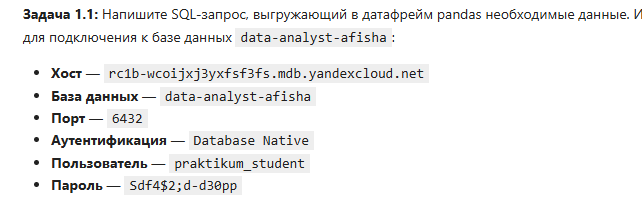
    
<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__    
    
    
Можно еще добавить readme.md, где указать ключевые моменты проекта. Или зафиксировать цели и полученные выводы.

<div class="alert alert-info"> <b>Комментарии студента:</b> исправлено </div>